<a href="https://www.kaggle.com/code/lalit7881/gold-price-history-1833-2026-eda-v1?scriptVersionId=315469029" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/uzmaakhtar/gold-price-history-18332026/monthly.csv
/kaggle/input/datasets/uzmaakhtar/gold-price-history-18332026/gold_advanced_features.csv


In [2]:
df = pd.read_csv("/kaggle/input/datasets/uzmaakhtar/gold-price-history-18332026/gold_advanced_features.csv")

In [3]:
df.head(
)

,date,price,year,month,quarter,month_sin,month_cos,lag_1,lag_2,lag_3,...,roll_std_6,momentum_1,momentum_3,pct_change_1,pct_change_3,ewm_3,ewm_6,price_to_roll3,price_to_roll12,volatility_3
0,1834-01-01,18.93,1834,1,1,0.500000,8.660254e-01,18.93,18.93,18.93,...,0.0,0.0,0.0,0.0,0.0,18.93,18.93,1.0,1.0,0.0
1,1834-02-01,18.93,1834,2,1,0.866025,5.000000e-01,18.93,18.93,18.93,...,0.0,0.0,0.0,0.0,0.0,18.93,18.93,1.0,1.0,0.0
2,1834-03-01,18.93,1834,3,1,1.000000,6.123234e-17,18.93,18.93,18.93,...,0.0,0.0,0.0,0.0,0.0,18.93,18.93,1.0,1.0,0.0
3,1834-04-01,18.93,1834,4,2,0.866025,-5.000000e-01,18.93,18.93,18.93,...,0.0,0.0,0.0,0.0,0.0,18.93,18.93,1.0,1.0,0.0
4,1834-05-01,18.93,1834,5,2,0.500000,-8.660254e-01,18.93,18.93,18.93,...,0.0,0.0,0.0,0.0,0.0,18.93,18.93,1.0,1.0,0.0


In [4]:
df.tail()

,date,price,year,month,quarter,month_sin,month_cos,lag_1,lag_2,lag_3,...,roll_std_6,momentum_1,momentum_3,pct_change_1,pct_change_3,ewm_3,ewm_6,price_to_roll3,price_to_roll12,volatility_3
2301,2025-10-01,4058.33,2025,10,4,-8.660254e-01,0.500000,3667.68,3368.03,3340.15,...,296.402871,390.65,718.18,0.106511,0.215014,3779.993234,3557.073542,1.097435,1.274842,346.148243
2302,2025-11-01,4087.19,2025,11,4,-5.000000e-01,0.866025,4058.33,3667.68,3368.03,...,352.702120,28.86,719.16,0.007111,0.213525,3933.591617,3708.535387,1.037955,1.237391,234.317791
2303,2025-12-01,4309.23,2025,12,4,-2.449294e-16,1.000000,4087.19,4058.33,3667.68,...,405.940932,222.04,641.55,0.054326,0.174920,4121.410808,3880.162419,1.037973,1.252135,137.286483
2304,2026-01-01,4752.75,2026,1,1,5.000000e-01,0.866025,4309.23,4087.19,4058.33,...,484.401566,443.52,694.42,0.102923,0.171110,4437.080404,4129.473157,1.084346,1.315909,338.866214
2305,2026-02-01,5019.97,2026,2,1,8.660254e-01,0.500000,4752.75,4309.23,4087.19,...,495.062966,267.22,932.78,0.056224,0.228220,4728.525202,4383.900826,1.069448,1.324927,358.995791


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2306 entries, 0 to 2305
Data columns (total 26 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   date             2306 non-null   object 
 1   price            2306 non-null   float64
 2   year             2306 non-null   int64  
 3   month            2306 non-null   int64  
 4   quarter          2306 non-null   int64  
 5   month_sin        2306 non-null   float64
 6   month_cos        2306 non-null   float64
 7   lag_1            2306 non-null   float64
 8   lag_2            2306 non-null   float64
 9   lag_3            2306 non-null   float64
 10  lag_6            2306 non-null   float64
 11  lag_12           2306 non-null   float64
 12  roll_mean_3      2306 non-null   float64
 13  roll_mean_6      2306 non-null   float64
 14  roll_mean_12     2306 non-null   float64
 15  roll_std_3       2306 non-null   float64
 16  roll_std_6       2306 non-null   float64
 17  momentum_1    

In [6]:
df.describe()

,price,year,month,quarter,month_sin,month_cos,lag_1,lag_2,lag_3,lag_6,...,roll_std_6,momentum_1,momentum_3,pct_change_1,pct_change_3,ewm_3,ewm_6,price_to_roll3,price_to_roll12,volatility_3
count,2306.000000,2306.000000,2306.000000,2306.000000,2.306000e+03,2.306000e+03,2306.000000,2306.000000,2306.000000,2306.000000,...,2306.000000,2306.000000,2306.000000,2306.000000,2306.000000,2306.000000,2306.000000,2306.000000,2306.000000,2306.000000
mean,233.342338,1929.583695,6.495663,2.498699,5.923788e-04,5.923788e-04,231.173631,229.120803,227.260309,222.162126,...,9.751816,2.168708,6.082029,0.002817,0.008787,231.300016,228.610150,1.002470,1.013892,6.529480
std,509.783501,55.485647,3.454473,1.118664,7.072599e-01,7.072599e-01,499.954410,491.019390,483.625365,464.712320,...,29.778583,24.735230,53.030386,0.029008,0.060051,500.487763,489.303382,0.022755,0.069160,21.124881
min,17.060000,1834.000000,1.000000,1.000000,-1.000000e+00,-1.000000e+00,17.060000,17.060000,17.060000,17.060000,...,0.000000,-111.740000,-249.736000,-0.173850,-0.233819,17.060876,17.123316,0.876745,0.752096,0.000000
25%,18.940000,1882.000000,3.000000,1.000000,-5.000000e-01,-5.000000e-01,18.940000,18.940000,18.940000,18.940000,...,0.000000,0.000000,0.000000,0.000000,0.000000,18.939453,18.937603,1.000000,1.000000,0.000000
50%,20.690000,1930.000000,6.000000,2.000000,1.224647e-16,6.123234e-17,20.685000,20.680000,20.680000,20.680000,...,0.000000,0.000000,0.000000,0.000000,0.000000,20.671443,20.658351,1.000000,1.000000,0.000000
75%,179.240000,1978.000000,9.000000,3.000000,7.745191e-01,7.745191e-01,178.155000,177.682500,176.300000,172.945000,...,5.254702,0.000000,0.000000,0.000000,0.000000,176.537120,172.620429,1.000000,1.001614,2.985347
max,5019.970000,2026.000000,12.000000,4.000000,1.000000e+00,1.000000e+00,4752.750000,4309.230000,4087.190000,3368.030000,...,495.062966,443.520000,932.780000,0.483937,0.724225,4728.525202,4383.900826,1.330765,1.963091,358.995791


In [7]:
df.isnull().sum()

date               0
price              0
year               0
month              0
quarter            0
month_sin          0
month_cos          0
lag_1              0
lag_2              0
lag_3              0
lag_6              0
lag_12             0
roll_mean_3        0
roll_mean_6        0
roll_mean_12       0
roll_std_3         0
roll_std_6         0
momentum_1         0
momentum_3         0
pct_change_1       0
pct_change_3       0
ewm_3              0
ewm_6              0
price_to_roll3     0
price_to_roll12    0
volatility_3       0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

date                object
price              float64
year                 int64
month                int64
quarter              int64
month_sin          float64
month_cos          float64
lag_1              float64
lag_2              float64
lag_3              float64
lag_6              float64
lag_12             float64
roll_mean_3        float64
roll_mean_6        float64
roll_mean_12       float64
roll_std_3         float64
roll_std_6         float64
momentum_1         float64
momentum_3         float64
pct_change_1       float64
pct_change_3       float64
ewm_3              float64
ewm_6              float64
price_to_roll3     float64
price_to_roll12    float64
volatility_3       float64
dtype: object

In [10]:
df.shape

(2306, 26)

In [11]:
df.columns

Index(['date', 'price', 'year', 'month', 'quarter', 'month_sin', 'month_cos',
       'lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12', 'roll_mean_3',
       'roll_mean_6', 'roll_mean_12', 'roll_std_3', 'roll_std_6', 'momentum_1',
       'momentum_3', 'pct_change_1', 'pct_change_3', 'ewm_3', 'ewm_6',
       'price_to_roll3', 'price_to_roll12', 'volatility_3'],
      dtype='object')

In [12]:
df.nunique()

date               2306
price               734
year                193
month                12
quarter               4
month_sin            11
month_cos            11
lag_1               733
lag_2               732
lag_3               731
lag_6               728
lag_12              722
roll_mean_3         826
roll_mean_6         950
roll_mean_12       1207
roll_std_3          811
roll_std_6          993
momentum_1          715
momentum_3          729
pct_change_1        755
pct_change_3        756
ewm_3              1648
ewm_6              1729
price_to_roll3      811
price_to_roll12    1312
volatility_3        811
dtype: int64

## EDA

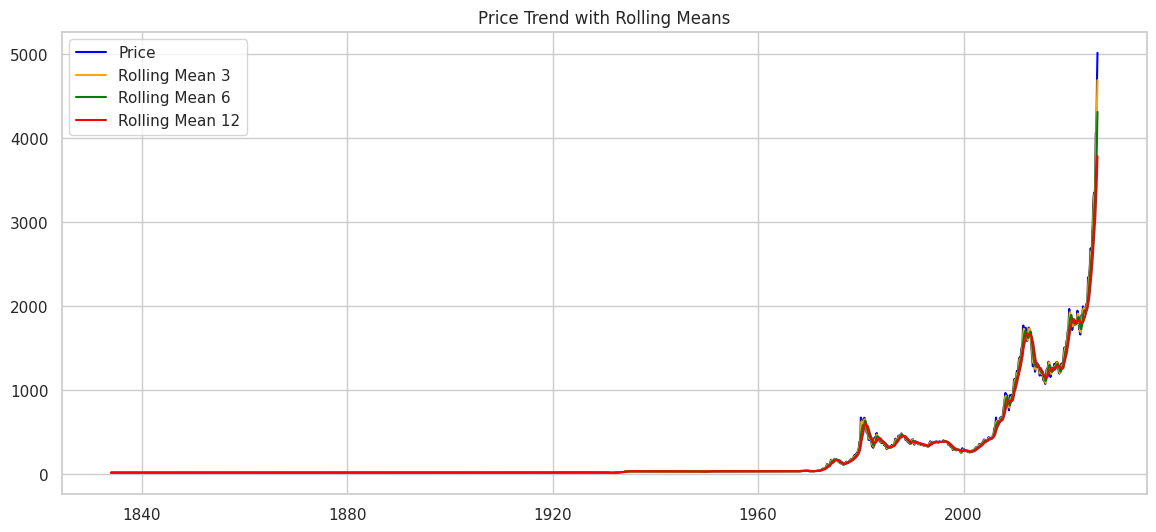

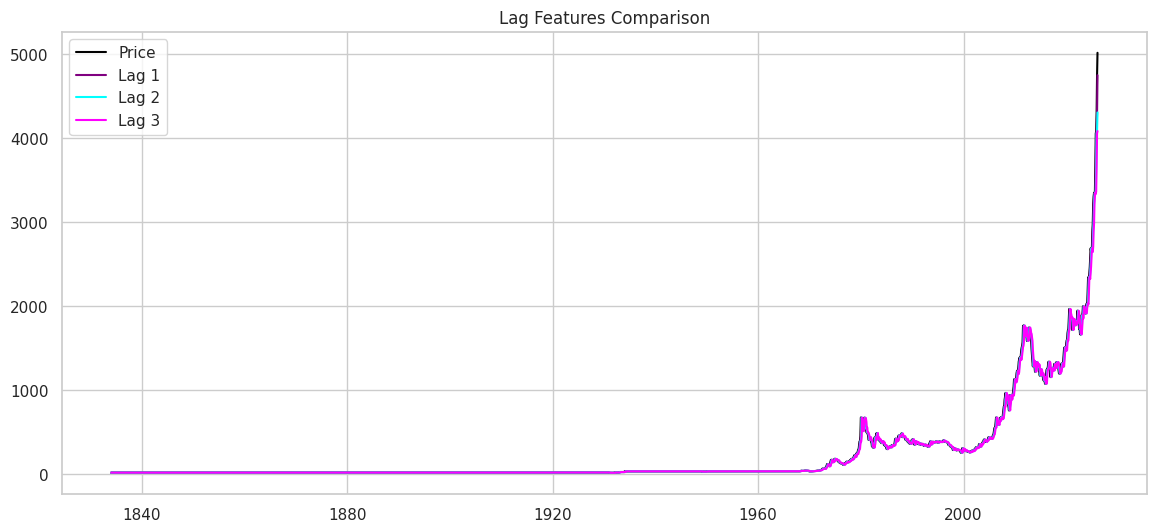

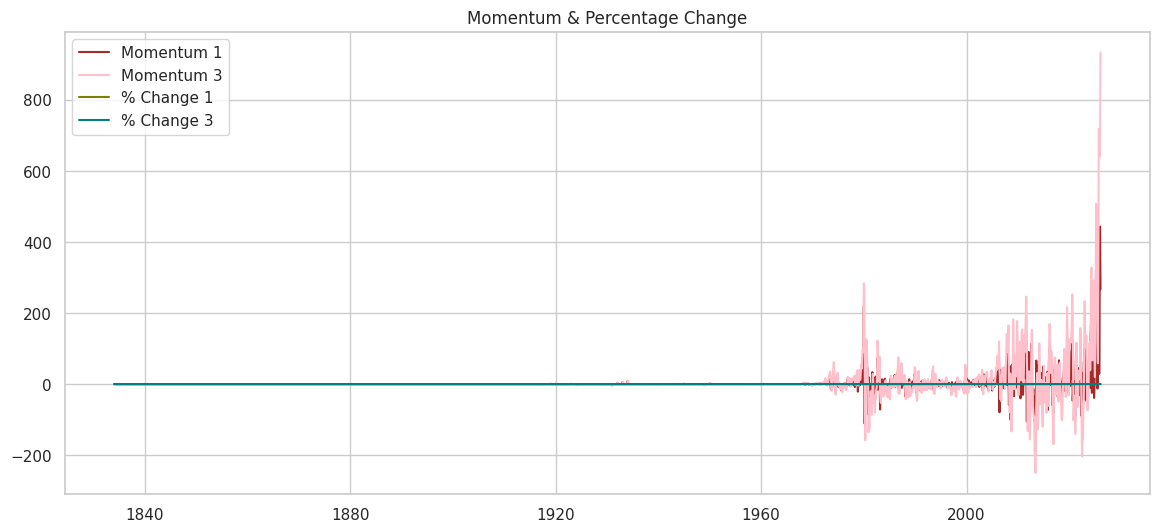

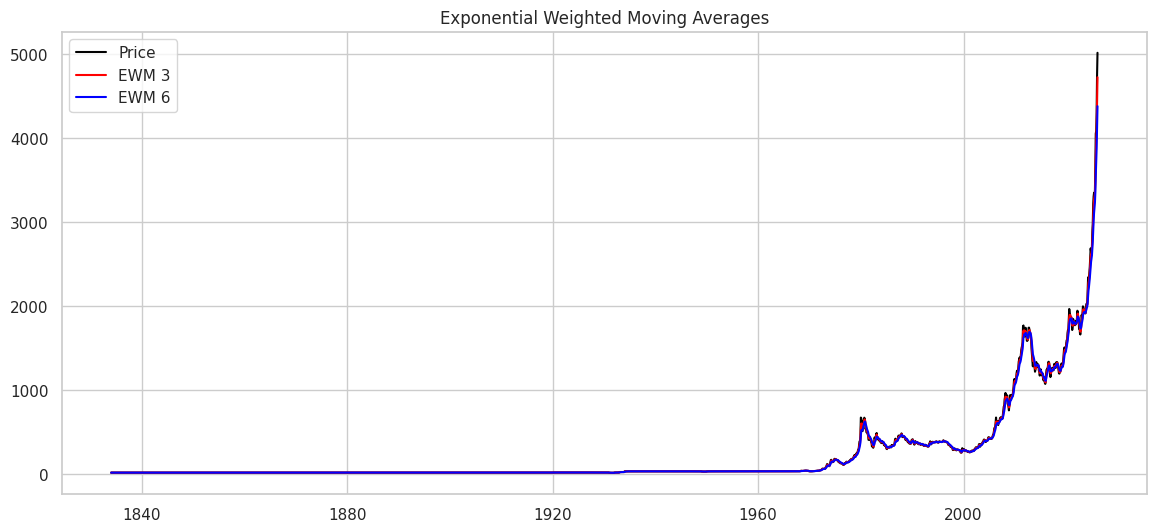

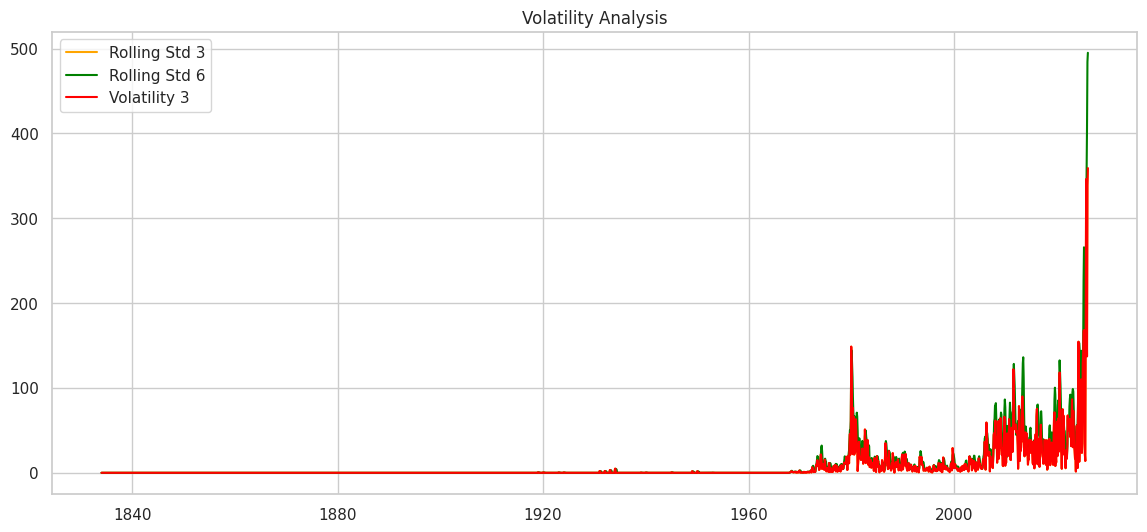

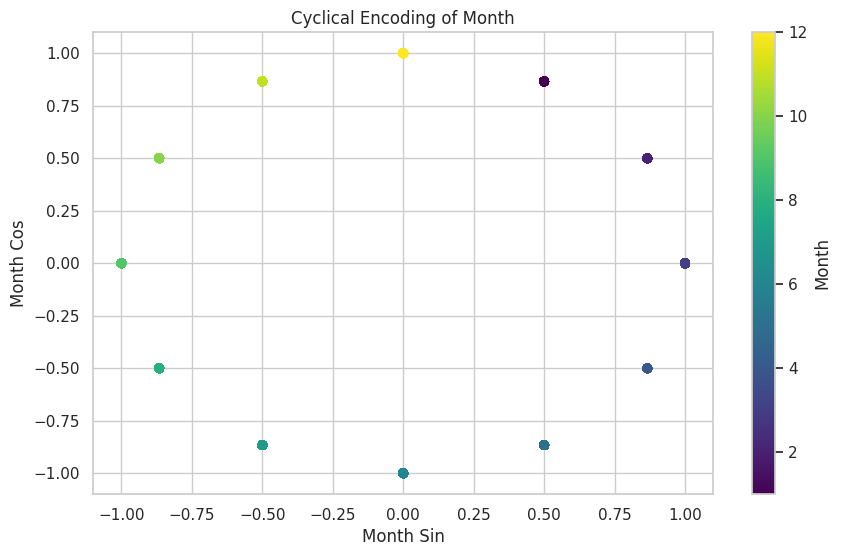

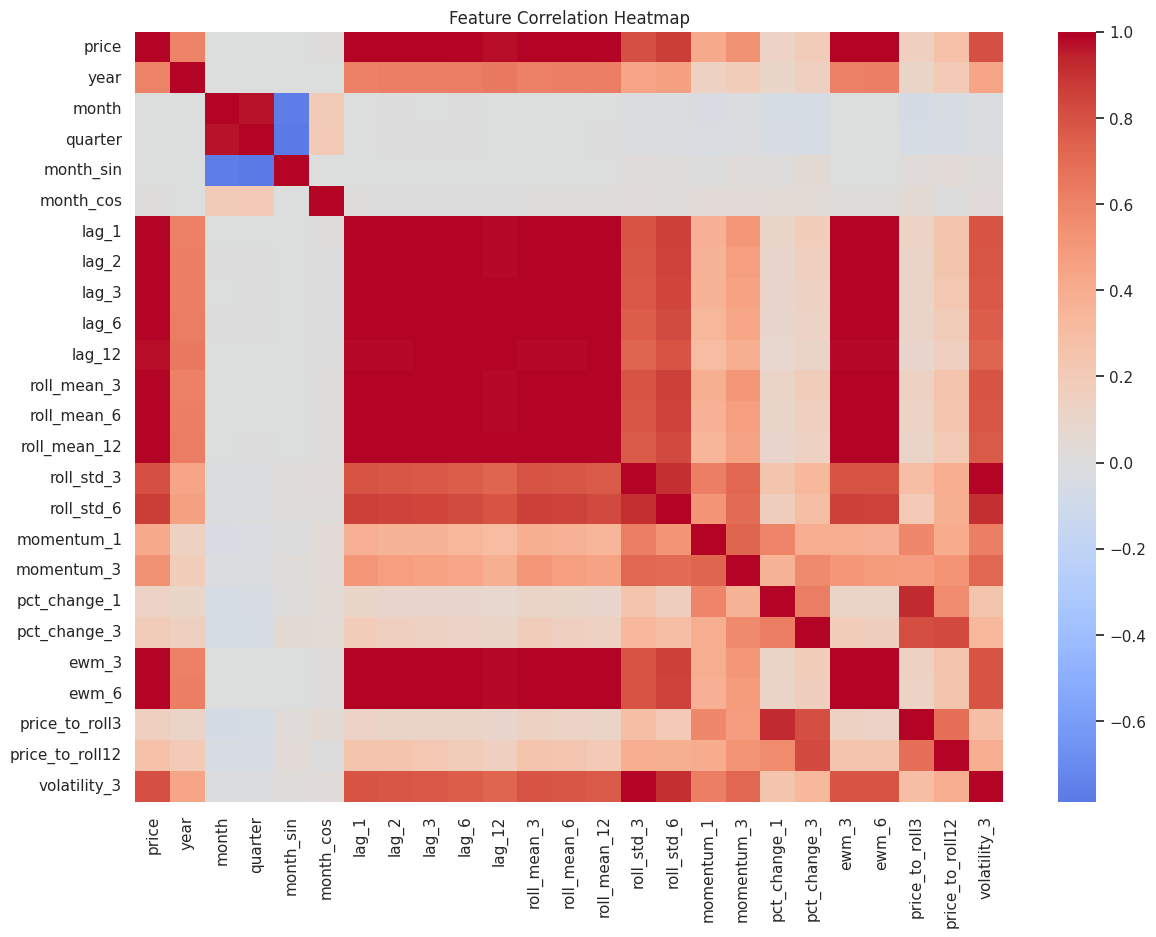

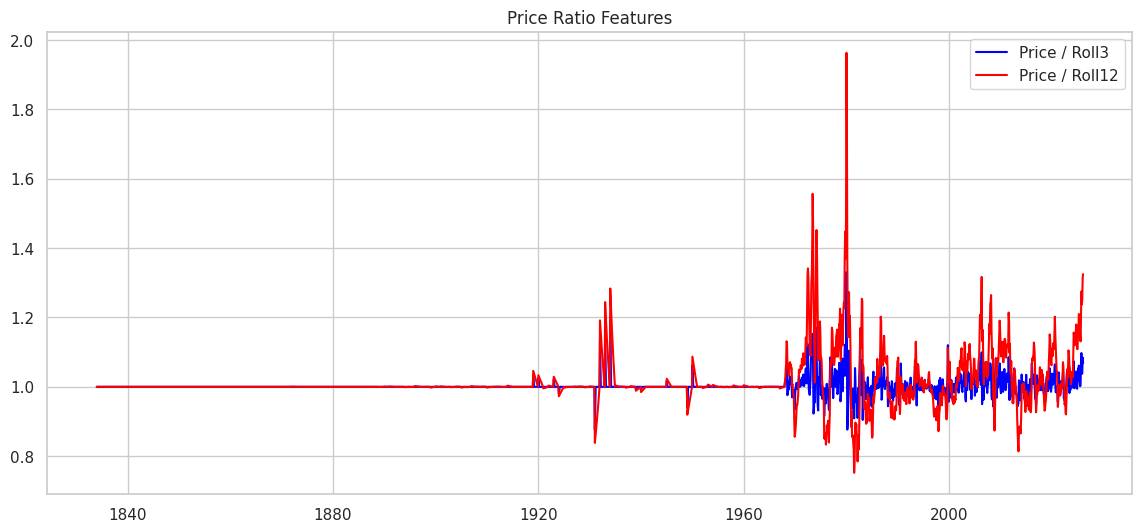

In [13]:
# Set style
sns.set(style="whitegrid")

# Convert date if not already
df['date'] = pd.to_datetime(df['date'])

# Sort by date
df = df.sort_values('date')

# -------------------------------
# 1. Price Trend with Rolling Means
# -------------------------------
plt.figure(figsize=(14, 6))
plt.plot(df['date'], df['price'], label='Price', color='blue')
plt.plot(df['date'], df['roll_mean_3'], label='Rolling Mean 3', color='orange')
plt.plot(df['date'], df['roll_mean_6'], label='Rolling Mean 6', color='green')
plt.plot(df['date'], df['roll_mean_12'], label='Rolling Mean 12', color='red')
plt.title("Price Trend with Rolling Means")
plt.legend()
plt.show()

# -------------------------------
# 2. Lag Features Visualization
# -------------------------------
plt.figure(figsize=(14, 6))
plt.plot(df['date'], df['price'], label='Price', color='black')
plt.plot(df['date'], df['lag_1'], label='Lag 1', color='purple')
plt.plot(df['date'], df['lag_2'], label='Lag 2', color='cyan')
plt.plot(df['date'], df['lag_3'], label='Lag 3', color='magenta')
plt.title("Lag Features Comparison")
plt.legend()
plt.show()

# -------------------------------
# 3. Momentum & Percentage Change
# -------------------------------
plt.figure(figsize=(14, 6))
plt.plot(df['date'], df['momentum_1'], label='Momentum 1', color='brown')
plt.plot(df['date'], df['momentum_3'], label='Momentum 3', color='pink')
plt.plot(df['date'], df['pct_change_1'], label='% Change 1', color='olive')
plt.plot(df['date'], df['pct_change_3'], label='% Change 3', color='teal')
plt.title("Momentum & Percentage Change")
plt.legend()
plt.show()

# -------------------------------
# 4. Exponential Weighted Means
# -------------------------------
plt.figure(figsize=(14, 6))
plt.plot(df['date'], df['price'], label='Price', color='black')
plt.plot(df['date'], df['ewm_3'], label='EWM 3', color='red')
plt.plot(df['date'], df['ewm_6'], label='EWM 6', color='blue')
plt.title("Exponential Weighted Moving Averages")
plt.legend()
plt.show()

# -------------------------------
# 5. Volatility & Rolling Std
# -------------------------------
plt.figure(figsize=(14, 6))
plt.plot(df['date'], df['roll_std_3'], label='Rolling Std 3', color='orange')
plt.plot(df['date'], df['roll_std_6'], label='Rolling Std 6', color='green')
plt.plot(df['date'], df['volatility_3'], label='Volatility 3', color='red')
plt.title("Volatility Analysis")
plt.legend()
plt.show()

# -------------------------------
# 6. Cyclical Features (Month Encoding)
# -------------------------------
plt.figure(figsize=(10, 6))
plt.scatter(df['month_sin'], df['month_cos'], c=df['month'], cmap='viridis')
plt.colorbar(label='Month')
plt.title("Cyclical Encoding of Month")
plt.xlabel("Month Sin")
plt.ylabel("Month Cos")
plt.show()

# -------------------------------
# 7. Correlation Heatmap
# -------------------------------
plt.figure(figsize=(14, 10))
corr = df.drop(columns=['date']).corr()
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

# -------------------------------
# 8. Price Ratios
# -------------------------------
plt.figure(figsize=(14, 6))
plt.plot(df['date'], df['price_to_roll3'], label='Price / Roll3', color='blue')
plt.plot(df['date'], df['price_to_roll12'], label='Price / Roll12', color='red')
plt.title("Price Ratio Features")
plt.legend()
plt.show()

## Feature engineering


Logistic Regression
Accuracy: 0.5195
AUC: 0.5263

Random Forest
Accuracy: 0.4307
AUC: 0.4283

Gradient Boosting
Accuracy: 0.4654
AUC: 0.4474


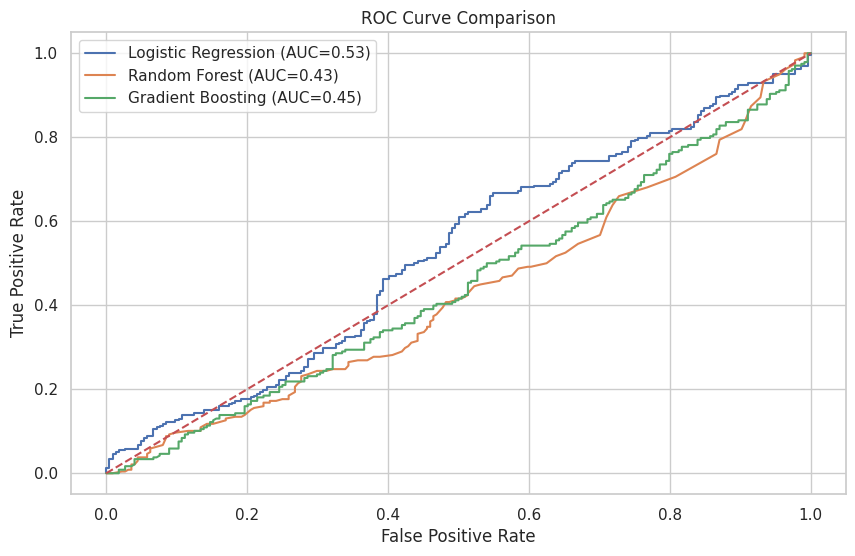


Final Model Comparison:
                     Accuracy       AUC
Logistic Regression  0.519481  0.526261
Gradient Boosting    0.465368  0.447413
Random Forest        0.430736  0.428337


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_curve, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier


df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

# -------------------------------
# 2. Create Target (NO LEAKAGE)
# Example: predict whether price increases next step
# -------------------------------
df['target'] = (df['price'].shift(-1) > df['price']).astype(int)

# Drop last row (NaN target)
df = df.dropna()

# -------------------------------
# 3. Feature Selection
# -------------------------------
features = [
    'price', 'year', 'month', 'quarter',
    'month_sin', 'month_cos',
    'lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12',
    'roll_mean_3', 'roll_mean_6', 'roll_mean_12',
    'roll_std_3', 'roll_std_6',
    'momentum_1', 'momentum_3',
    'pct_change_1', 'pct_change_3',
    'ewm_3', 'ewm_6',
    'price_to_roll3', 'price_to_roll12',
    'volatility_3'
]

X = df[features]
y = df['target']

# -------------------------------
# 4. Train-Test Split (TIME SERIES SAFE)
# -------------------------------
split_index = int(len(df) * 0.8)

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

# -------------------------------
# 5. Scaling (FIT ONLY ON TRAIN)
# -------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -------------------------------
# 6. Models
# -------------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier()
}

results = {}

# -------------------------------
# 7. Training + Evaluation
# -------------------------------
plt.figure(figsize=(10, 6))

for name, model in models.items():
    
    # Train
    model.fit(X_train_scaled, y_train)
    
    # Predictions
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    
    results[name] = (acc, auc)
    
    print(f"\n{name}")
    print(f"Accuracy: {acc:.4f}")
    print(f"AUC: {auc:.4f}")
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.2f})")

# -------------------------------
# 8. ROC Curve Plot
# -------------------------------
plt.plot([0, 1], [0, 1], linestyle='--')  # random line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

# -------------------------------
# 9. Results Summary
# -------------------------------
results_df = pd.DataFrame(results, index=['Accuracy', 'AUC']).T
print("\nFinal Model Comparison:")
print(results_df.sort_values(by='AUC', ascending=False))

In [15]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

from sklearn.metrics import accuracy_score, roc_auc_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_proba))

Accuracy: 0.4588744588744589
AUC: 0.42476365546218486


## Thank you...pls upvote!!!!!!!!!!!!